In [2]:
# LV Side

v_shdn_loop = 24 #V
vf_schottky = 0.2 #V
vf_LED = 3 #V
vf_opto = 0.7 #V

desired_opto_current = 0.04 #A

r_opto_input_desired = (v_shdn_loop - vf_schottky - vf_LED - vf_opto)/desired_opto_current
print(r_opto_input_desired) #Ohms

r_opto_input_actual = 470 #Ohms
opto_current_actual = (v_shdn_loop - vf_schottky - vf_LED - vf_opto)/r_opto_input_actual
print(opto_current_actual * 10**3) #mA

# abs max for this part is 50mA. 42.8mA is acceptable against this requirement.

502.5
42.765957446808514


In [3]:
# Resistor Calculations

discharge_resistor = 4700 #Ohms
number_series = 2
number_parallel = 2
effective_resistance = discharge_resistor*number_series/number_parallel
print(effective_resistance)

4700.0


In [4]:
# MOSFET Calculations

max_pack_voltage = 588
equivalent_resistance = 4700
rds_on = 16

peak_current = max_pack_voltage/equivalent_resistance
print(peak_current) #A

mosfet_peak_power = rds_on*peak_current**2
print(mosfet_peak_power) #W



0.1251063829787234
0.25042571299230415


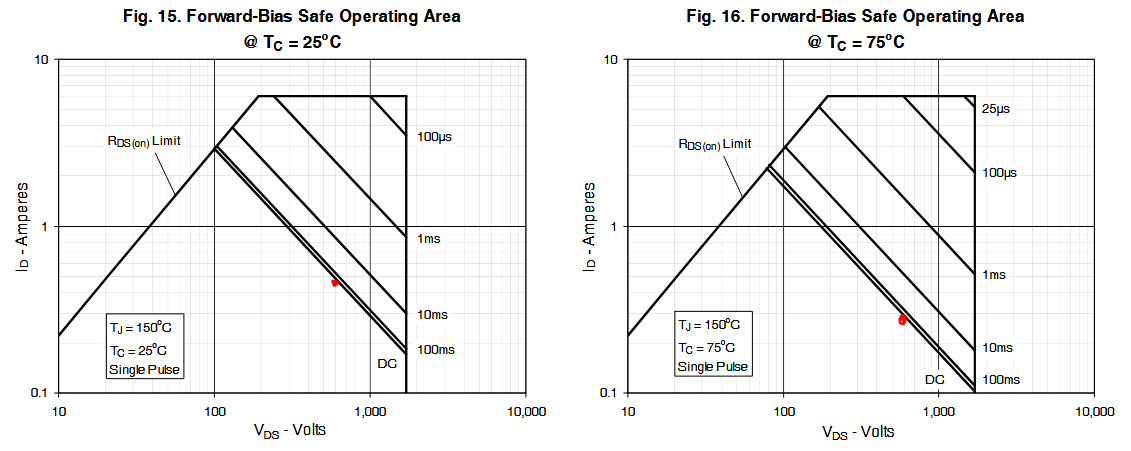

The peak current here is under the threshold imposed by both figures, indicating that this MOSFET (IXTA1N170DHV) can support the proposed use-case and inturrupt discharge when requested.

In [15]:
Tmax = 175
p_dis = (max_pack_voltage**2)/effective_resistance
Ror = 1.3
Ta = 75
print(p_dis)

Roh = (Tmax-(p_dis*Ror)-Ta)/p_dis
print(Roh)

73.56255319148936
0.05938729233189873


In [9]:
bus_capacitance = 300*10**-6
discharge_energy = 0.5*bus_capacitance*max_pack_voltage**2
print(discharge_energy)

51.861599999999996


In [12]:
aluminum_specific_heat_capacity = 0.896 #J/(g degC)
heatsink_mass = 350 #g
heatsink_heat_capacity = heatsink_mass*aluminum_specific_heat_capacity
discharge_temp_rise = discharge_energy/heatsink_heat_capacity
print(discharge_temp_rise)


0.16537499999999997


In [24]:
resistor_pad_area = 0.025*0.038
TIM_thermal_resistance = 0.0002/resistor_pad_area
print(TIM_thermal_resistance)
t_rise = TIM_thermal_resistance*p_dis
print(t_rise)

0.2105263157894737
15.486853303471445


Resistor can do required 73W as long as bottom case does not exceed 120C.
Based upon TIM_t_rise of 15.5 calculated above, this shows a maximum heatsink temperature of 104.5 deg C